# Cancellations, days open, and applicant caps

Three questions about federal job postings: what share get cancelled, how long
they stay open, and how many cap the number of applications they'll accept.

Two data sources, and they answer different slices of this:

- `../data/mirror-cache/historical_jobs_*.parquet` -- the `historicjoa` API, one row
  per announcement, 2013 through today. This is complete and reliable for
  cancellation rate and days-open, across the whole history. Coverage before
  2017 is too thin to use (a few hundred rows some years); those years are
  dropped below.
- `data/current_jobs_2024/2025/2026.parquet` -- the *live Search API*, snapshotted
  daily since 2024-07-08 for whatever's currently open. This is the only source
  for applicant caps, and only from when it started.

The cap story is the reason this notebook exists, and it's worth telling
before the numbers: caps looked almost nonexistent at first -- regexing the
announcement text for phrases like "received 50 applications" found them in
maybe 1% of "Applicant Cut-Off" postings. That undercounts by roughly 100x.
The real number lives in a structured API field, `AnnouncementClosingTypeOption`,
that nothing in this pipeline had ever extracted -- confirmed by hitting the
live API directly and finding `"AnnouncementClosingTypeOption": "50"` sitting
right next to the code that names the closing type. `collect_current_data.py`
was already saving the entire raw API response into a `MatchedObjectDescriptor`
JSON column and just never promoted this field out of it, so recovering it for
everything collected since 2024-07 took a local backfill pass, not new scraping
(`scripts/backfill_current_jobs_fields.py`). The pipeline itself is now fixed
to capture it going forward. The `historicjoa` API behind the pre-2024 archive
has no equivalent field at all -- that part of history is genuinely gone,
except for the rare posting that also typed the number into its prose.

## Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

con = duckdb.connect()

HISTORICAL = "../data/mirror-cache/historical_jobs_*.parquet"
CURRENT = "../data/current_jobs_202*.parquet"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
BLUE = "#2f6fed"
RED = "#d64545"
GRAY = "#888888"


## 1. Cancellation rate by year

`positionOpeningStatus` on the historical file already resolves to a final
state: `Job canceled`, `Candidate selected`, `Job closed`, or (for postings
still working through the pipeline) `Applications under review` /
`Accepting applications`. A raw cancelled/total ratio understates recent years,
because a lot of 2025-2026 postings haven't resolved yet -- so the honest
denominator is *resolved* postings only (cancelled + selected + closed).

In [2]:
RESOLVED = "('Job canceled', 'Candidate selected', 'Job closed')"

cancel_by_year = con.sql(f"""
    SELECT extract(year from try_cast(positionOpenDate AS DATE)) AS year,
           count(*) FILTER (WHERE positionOpeningStatus IN {RESOLVED}) AS resolved,
           count(*) FILTER (WHERE positionOpeningStatus = 'Job canceled') AS cancelled,
           round(100.0 * count(*) FILTER (WHERE positionOpeningStatus = 'Job canceled')
                 / count(*) FILTER (WHERE positionOpeningStatus IN {RESOLVED}), 1) AS pct_cancelled
    FROM read_parquet('{HISTORICAL}')
    WHERE try_cast(positionOpenDate AS DATE) BETWEEN '2017-01-01' AND '2026-12-31'
    GROUP BY 1 ORDER BY 1
""").df()
cancel_by_year

,year,resolved,cancelled,pct_cancelled
0,2017,99564,22391,22.5
1,2018,237679,38445,16.2
2,2019,265767,46381,17.5
3,2020,264612,43960,16.6
4,2021,322028,56544,17.6
5,2022,403985,70393,17.4
6,2023,421026,76483,18.2
7,2024,276906,67441,24.4
8,2025,96665,36388,37.6
9,2026,69738,20722,29.7


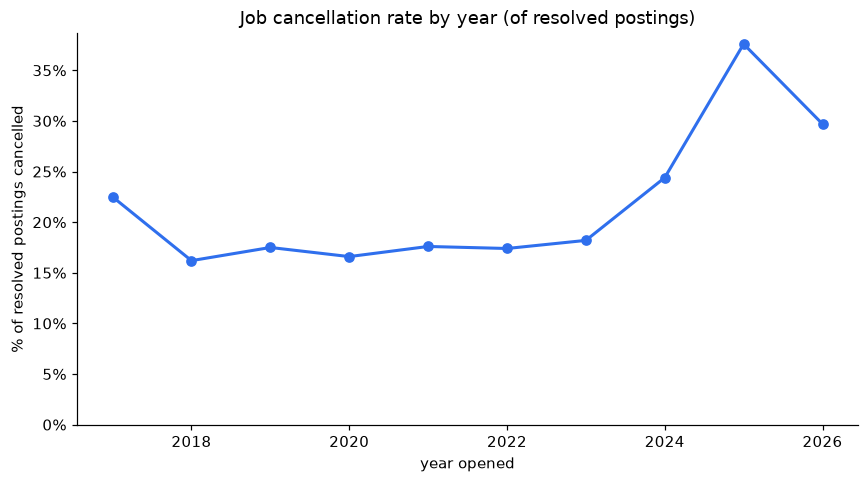

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cancel_by_year["year"], cancel_by_year["pct_cancelled"], marker="o", color=BLUE, linewidth=2)
ax.set_ylabel("% of resolved postings cancelled")
ax.set_xlabel("year opened")
ax.set_title("Job cancellation rate by year (of resolved postings)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

Cancellation held steady around 16-18% from 2018 through 2023, then climbed
sharply -- 24% in 2024, 38% in 2025. 2026 (29.7% so far) is a partial year and
still resolving, so treat it as a floor, not a final number: postings that end
up cancelled tend to reach that terminal status faster than postings that end
up filled, since cancellation doesn't wait on a hiring decision. That skews an
in-progress year's rate up, not down, so the true 2026 rate is probably at
least this high.

Worth being honest about what this can't distinguish: a jump like 2024→2025
could be more agencies actually cancelling postings, or it could be a change
in how fast *cancelled* postings in particular get repolled relative to
*filled* ones. The data here can't separate those two stories -- it would take
comparing repoll latency by outcome type, which is out of scope here.

## 2. How long postings stay open

`positionCloseDate - positionOpenDate` on the historical file -- the announced
window, not necessarily the date someone stopped accepting applications early
(a cancelled or applicant-cut-off posting can close before its announced date).

In [4]:
duration_by_year = con.sql(f"""
    SELECT extract(year from try_cast(positionOpenDate AS DATE)) AS year,
           count(*) FILTER (WHERE try_cast(positionCloseDate AS DATE) IS NOT NULL) AS n,
           median(date_diff('day', try_cast(positionOpenDate AS DATE), try_cast(positionCloseDate AS DATE)))
             FILTER (WHERE try_cast(positionCloseDate AS DATE) IS NOT NULL) AS median_days,
           round(100.0 * count(*) FILTER (WHERE date_diff('day', try_cast(positionOpenDate AS DATE),
                 try_cast(positionCloseDate AS DATE)) < 7 AND try_cast(positionCloseDate AS DATE) IS NOT NULL)
                 / count(*) FILTER (WHERE try_cast(positionCloseDate AS DATE) IS NOT NULL), 1) AS pct_under_a_week
    FROM read_parquet('{HISTORICAL}')
    WHERE try_cast(positionOpenDate AS DATE) BETWEEN '2017-01-01' AND '2026-12-31'
    GROUP BY 1 ORDER BY 1
""").df()
duration_by_year

,year,n,median_days,pct_under_a_week
0,2017,237146,13.0,21.2
1,2018,329356,12.0,21.8
2,2019,349256,12.0,21.4
3,2020,328440,12.0,21.5
4,2021,369151,13.0,18.4
5,2022,441604,13.0,15.8
6,2023,454652,13.0,15.3
7,2024,367192,12.0,17.0
8,2025,168359,12.0,14.5
9,2026,187253,10.0,19.8


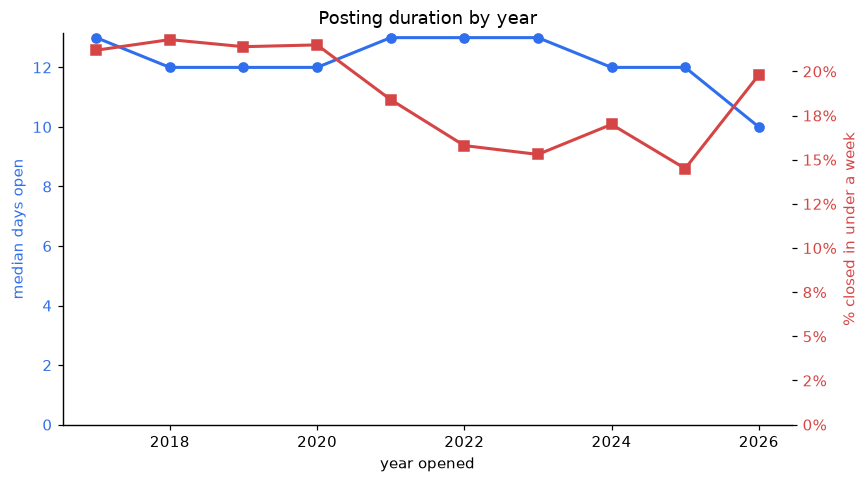

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(duration_by_year["year"], duration_by_year["median_days"], marker="o", color=BLUE, linewidth=2, label="median days open")
ax1.set_ylabel("median days open", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(duration_by_year["year"], duration_by_year["pct_under_a_week"], marker="s", color=RED, linewidth=2, label="% closed in <7 days")
ax2.set_ylabel("% closed in under a week", color=RED)
ax2.tick_params(axis="y", labelcolor=RED)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax2.set_ylim(bottom=0)

ax1.set_xlabel("year opened")
ax1.set_title("Posting duration by year")
plt.tight_layout()
plt.show()

Median days open is remarkably flat -- 12-13 days almost every year since
2017. The under-a-week share moves more (22% in 2017-2020, down to 14-16% in
2022-2025), which the median alone hides: OPM's minimum posting requirements
haven't changed, so this is agencies choosing shorter windows within what's
allowed, not a policy shift. 2026's numbers (10 median days, 19.8% under a
week) are partial-year and should be read the same way as the cancellation
rate above -- short windows resolve (and get repolled) faster, so an
in-progress year's distribution skews toward the fast-closing postings.

## 3. Applicant caps

Scoped to `current_jobs_*.parquet` (2024-07 onward) -- the only source with the
real `applicationCap` field. Monthly volume for the first several months of
this file is tiny (43-800 postings/month) because the collection pipeline
itself was still ramping up occupational-series coverage, not because few jobs
were open -- that's a pipeline-maturity artifact, not a signal about caps. Full
daily coverage looks stable from around 2025-07 onward, so the adoption trend
below is trustworthy from there; treat anything before it as noise.

In [6]:
caps_by_month = con.sql(f"""
    SELECT strftime(try_cast(positionOpenDate AS DATE), '%Y-%m') AS month,
           count(*) AS total_postings,
           count(*) FILTER (WHERE announcementClosingTypeCode = '03') AS cutoff_type,
           round(100.0 * count(*) FILTER (WHERE announcementClosingTypeCode = '03') / count(*), 1) AS pct_cutoff,
           median(applicationCap) FILTER (WHERE applicationCap IS NOT NULL) AS median_cap,
           count(*) FILTER (WHERE applicationCap IS NOT NULL AND applicationCap < 50) AS under_50
    FROM read_parquet('{CURRENT}')
    WHERE positionOpenDate IS NOT NULL
    GROUP BY 1 ORDER BY 1
""").df()
caps_by_month

,month,total_postings,cutoff_type,pct_cutoff,median_cap,under_50
0,2024-07,43,0,0.0,NaN,0
1,2024-08,39,0,0.0,NaN,0
2,2024-09,69,0,0.0,NaN,0
3,2024-10,210,0,0.0,NaN,0
4,2024-11,127,3,2.4,50.0,1
5,2024-12,96,2,2.1,25.0,2
6,2025-01,553,2,0.4,50.0,0
7,2025-02,514,3,0.6,50.0,1
8,2025-03,399,2,0.5,50.0,0
9,2025-04,597,6,1.0,50.0,0


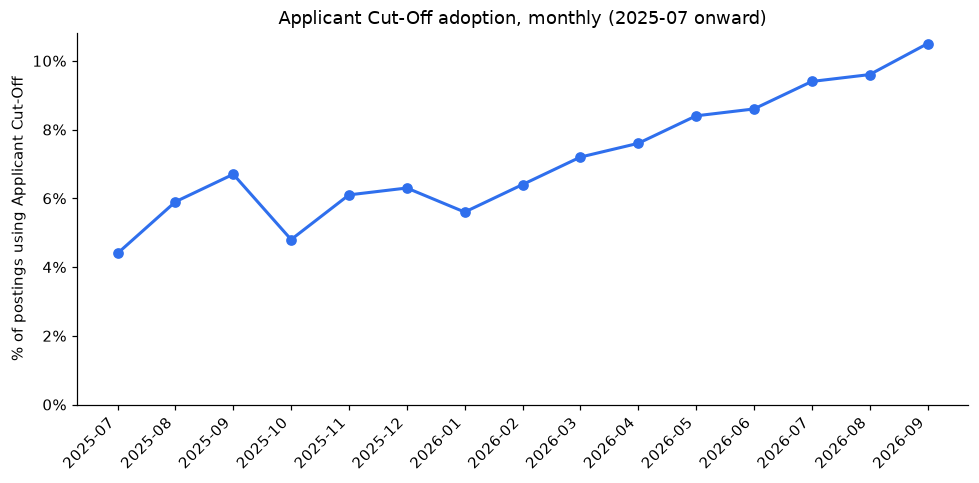

In [7]:
stable = caps_by_month[caps_by_month["month"] >= "2025-07"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(stable["month"], stable["pct_cutoff"], marker="o", color=BLUE, linewidth=2)
ax.set_ylabel("% of postings using Applicant Cut-Off")
ax.set_title("Applicant Cut-Off adoption, monthly (2025-07 onward)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(bottom=0)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

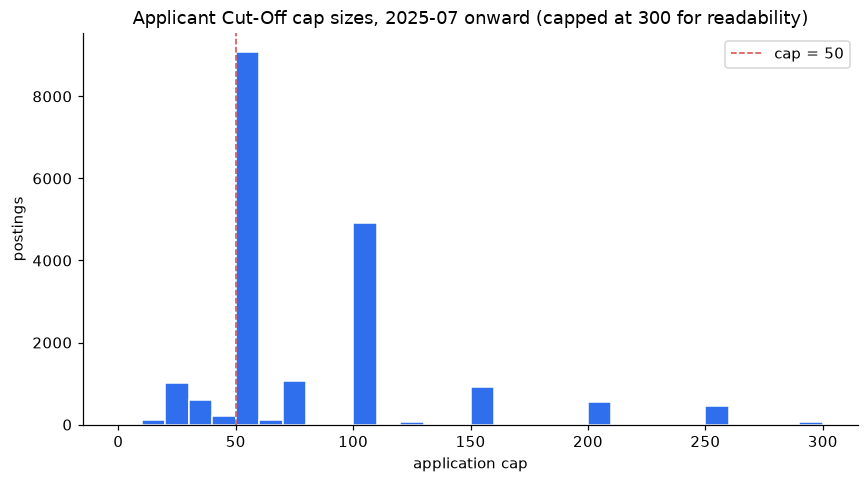

19,417 Applicant Cut-Off postings with a known cap, 2025-07 onward
1,944 (10.0%) capped under 50 applications
median cap: 50


In [8]:
cap_dist = con.sql(f"""
    SELECT applicationCap, count(*) AS n
    FROM read_parquet('{CURRENT}')
    WHERE announcementClosingTypeCode = '03' AND applicationCap IS NOT NULL
      AND positionOpenDate >= '2025-07-01'
    GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(cap_dist["applicationCap"].repeat(cap_dist["n"]), bins=range(0, 305, 10), color=BLUE, edgecolor="white")
ax.set_xlabel("application cap")
ax.set_ylabel("postings")
ax.set_title("Applicant Cut-Off cap sizes, 2025-07 onward (capped at 300 for readability)")
ax.axvline(50, color=RED, linestyle="--", linewidth=1, label="cap = 50")
ax.legend()
plt.tight_layout()
plt.show()

n_cutoff = int((cap_dist["n"]).sum())
n_under_50 = int(cap_dist.loc[cap_dist["applicationCap"] < 50, "n"].sum())
median_cap = int(cap_dist["applicationCap"].repeat(cap_dist["n"]).median())
print(f"{n_cutoff:,} Applicant Cut-Off postings with a known cap, 2025-07 onward")
print(f"{n_under_50:,} ({100*n_under_50/n_cutoff:.1f}%) capped under 50 applications")
print(f"median cap: {median_cap}")

Adoption of the Applicant Cut-Off closing type roughly doubled over about a
year -- from ~4-6% of new postings in mid-2025 to ~9-10% by September 2026.
50 is by far the most common cap (it's the median in nearly every month above),
which reads like agencies defaulting to a round number rather than sizing the
cap to the role. A meaningful share sit under 50, and a long tail runs into
the hundreds or, rarely, four figures.

Median days-open for a job with a cap under 50 (below) comes out to 9 days,
noticeably below the 12-13 day median from section 2 -- consistent with the
obvious mechanism: a low cap gets hit fast, and the posting closes on volume
rather than on its calendar date.

In [9]:
con.sql(f"""
    SELECT count(*) AS n,
           median(date_diff('day', try_cast(positionOpenDate AS DATE), try_cast(positionCloseDate AS DATE))) AS median_days_open
    FROM read_parquet('{CURRENT}')
    WHERE applicationCap IS NOT NULL AND applicationCap < 50
      AND try_cast(positionCloseDate AS DATE) IS NOT NULL
""").show()

┌───────┬──────────────────┐
│   n   │ median_days_open │
│ int64 │      double      │
├───────┼──────────────────┤
│  1959 │              9.0 │
└───────┴──────────────────┘



### Examples: capped under 50 *and* closing fast

The original ask that started this whole detour. With the real field in hand
instead of prose-mining, this is now an exact query, not a guess:

In [10]:
con.sql(f"""
    SELECT usajobsControlNumber, positionTitle, hiringAgencyName, applicationCap,
           positionOpenDate::DATE AS opened, positionCloseDate::DATE AS closes,
           date_diff('day', try_cast(positionOpenDate AS DATE), try_cast(positionCloseDate AS DATE)) AS days_open
    FROM read_parquet('{CURRENT}')
    WHERE applicationCap IS NOT NULL AND applicationCap < 50
      AND date_diff('day', try_cast(positionOpenDate AS DATE), try_cast(positionCloseDate AS DATE)) < 7
    ORDER BY positionOpenDate DESC
    LIMIT 15
""").show(max_width=140)

┌──────────────────────┬─────────────────────────────┬──────────────────────────────┬────────────────┬────────────┬────────────┬───────────┐
│ usajobsControlNumber │        positionTitle        │       hiringAgencyName       │ applicationCap │   opened   │   closes   │ days_open │
│        int64         │           varchar           │           varchar            │     double     │    date    │    date    │   int64   │
├──────────────────────┼─────────────────────────────┼──────────────────────────────┼────────────────┼────────────┼────────────┼───────────┤
│            884152300 │ Data Analyst Support Proje… │ National Institutes of Heal… │           25.0 │ 2026-09-21 │ 2026-09-25 │         4 │
│            884152400 │ AI-Enabled Portfolio Manag… │ National Institutes of Heal… │           25.0 │ 2026-09-21 │ 2026-09-25 │         4 │
│            884152500 │ Grants Management Analyst … │ National Institutes of Heal… │           25.0 │ 2026-09-21 │ 2026-09-25 │         4 │
│            

## 4. Signals of a "wired" posting

A posting can be technically open and still not be a real competition: restricted
to internal candidates, capped low enough to close before most people see it, or
both. Two fields carry pieces of this, and neither is as clean as it first looks.

`whoMayApply` (historical file only) looked like a full-archive signal at first,
but checking its fill rate by year kills that: 99% filled in 2016-2017, 21% in
2018, then effectively zero from 2019 onward (0-45 rows out of 170K-450K per
year -- not a sampling issue, the field just stopped being set). So it's a
snapshot of 2016-2018 hiring practice, not something that says anything about
2024-2026. Restricting the query to that window is what makes it honest:

In [11]:
whoapply = con.sql(f"""
    SELECT whoMayApply,
           count(*) AS n,
           median(date_diff('day', try_cast(positionOpenDate AS DATE), try_cast(positionCloseDate AS DATE)))
             FILTER (WHERE try_cast(positionCloseDate AS DATE) IS NOT NULL) AS median_days,
           round(100.0 * count(*) FILTER (WHERE date_diff('day', try_cast(positionOpenDate AS DATE),
                 try_cast(positionCloseDate AS DATE)) < 7 AND try_cast(positionCloseDate AS DATE) IS NOT NULL)
                 / count(*) FILTER (WHERE try_cast(positionCloseDate AS DATE) IS NOT NULL), 1) AS pct_under_a_week
    FROM read_parquet('{HISTORICAL}')
    WHERE whoMayApply IS NOT NULL
      AND try_cast(positionOpenDate AS DATE) BETWEEN '2016-01-01' AND '2018-12-31'
    GROUP BY 1 ORDER BY n DESC
""").df()
whoapply

,whoMayApply,n,median_days,pct_under_a_week
0,Status Candidates (Merit Promotion and VEOA El...,112533,10.0,24.2
1,United States Citizens,86659,13.0,24.2
2,Agency Employees Only,54208,13.0,14.3
3,Public,23394,14.0,17.3
4,US Citizens and Non-Citizens,11598,12.0,16.7
5,US Citizens and Status Candidates,8184,14.0,6.7
6,All groups of qualified individuals,7743,15.0,3.7
7,Student/Internship Program Eligibles,3117,8.0,37.2
8,Qualified ICTAP or VEOA Eligibles,1013,4.0,80.1
9,Qualified Current Civil Service Employees,457,14.0,15.3


`Qualified ICTAP or VEOA Eligibles` jumps out: median 4 days open, 80.1%
closed inside a week (in 2016-2018). Worth being precise about what this is,
because "closes fast" invites a story that isn't quite right: it's not that
agencies rush these to keep ICTAP/VEOA-eligible people off some shared
certificate. It's a separate, parallel announcement -- only people in that
eligibility category can apply to *that specific announcement number* -- and
in practice it's usually posted alongside a companion announcement for the
exact same job under a different eligibility restriction. Real example from
the data: control #465747700 ("USAR Unit Administrator," Army Reserve, opened
2017-03-14) has companion postings #465638000, #465640900, #465651000... all
the same title, agency, and open date, different announcement numbers,
restricted to "Status Candidates (Merit Promotion and VEOA Eligibles)." Each
announcement number produces its own certificate -- they aren't merged -- so
the fast close reads as "this track's eligible pool is small and known," not
as an attempt to keep it out of the real competition. `Status Candidates`
itself (current/former federal employees only, 112,533 postings, the largest
restricted category in this window) also closes faster and more often under a
week than `Public` does -- a milder version of the same shape.

None of this reaches 2024-2026, which is the window `applicationCap` actually
exists for. Checked whether historical_jobs could fill that gap by joining on
control number: 269,329 of 269,358 current_jobs control numbers (99.99%) do
eventually show up in historical_jobs once OPM's archive picks them up, so the
join itself works. It just doesn't help here -- `whoMayApply` is 0% filled in
that overlap too, same dead field on both sides. `HiringPaths` (current_jobs
only, 2024-07 onward) is the only usable "who can apply" signal for the recent
era, denser than whoMayApply ever was, but with its own wrinkle: the same
value appears under two spellings depending on when it was collected
(`"public"` vs `"The public"`, `"fed-internal-search"` vs `"Internal to an
agency"`) -- whatever supplied the code-to-name mapping wasn't always
available. What matters here is simpler than resolving every category: whether
a posting's path list includes *either* spelling of "the public" at all.

In [12]:
internal = con.sql(f"""
    WITH t AS (
        SELECT applicationCap, announcementClosingTypeCode,
               try_cast(positionOpenDate AS DATE) AS open_dt,
               try_cast(positionCloseDate AS DATE) AS close_dt,
               list_transform(json_transform(HiringPaths, '[{{\"hiringPath\":\"VARCHAR\"}}]'), x -> x.hiringPath) AS paths
        FROM read_parquet('{CURRENT}')
        WHERE HiringPaths IS NOT NULL
    )
    SELECT NOT (list_contains(paths, 'public') OR list_contains(paths, 'The public')) AS internal_only,
           count(*) AS n,
           median(date_diff('day', open_dt, close_dt)) FILTER (WHERE close_dt IS NOT NULL) AS median_days,
           round(100.0 * count(*) FILTER (WHERE date_diff('day', open_dt, close_dt) < 7 AND close_dt IS NOT NULL)
                 / count(*) FILTER (WHERE close_dt IS NOT NULL), 1) AS pct_under_a_week,
           round(100.0 * count(*) FILTER (WHERE announcementClosingTypeCode = '03') / count(*), 1) AS pct_capped
    FROM t GROUP BY 1
""").df()
internal

,internal_only,n,median_days,pct_under_a_week,pct_capped
0,False,142007,12.0,12.7,6.7
1,True,127639,9.0,26.6,7.8


Internal-only postings (no public path at all -- restricted to some
combination of current employees, veterans, agency staff, etc.) close in a
median of 9 days vs. 12 for public postings, and close under a week nearly
twice as often (26.6% vs 12.7%). The cap rate barely moves between the two
groups (7.8% vs 6.7%) -- restricting who can apply and capping how many can
apply look like two largely independent levers agencies reach for, not the
same lever twice.

In [13]:
wired = con.sql(f"""
    WITH t AS (
        SELECT usajobsControlNumber, positionTitle, hiringAgencyName, applicationCap,
               try_cast(positionOpenDate AS DATE) AS open_dt,
               try_cast(positionCloseDate AS DATE) AS close_dt,
               list_transform(json_transform(HiringPaths, '[{{\"hiringPath\":\"VARCHAR\"}}]'), x -> x.hiringPath) AS paths
        FROM read_parquet('{CURRENT}')
        WHERE HiringPaths IS NOT NULL AND announcementClosingTypeCode = '03'
    )
    SELECT usajobsControlNumber, positionTitle, hiringAgencyName, applicationCap,
           open_dt AS opened, close_dt AS closes, date_diff('day', open_dt, close_dt) AS days_open
    FROM t
    WHERE NOT (list_contains(paths, 'public') OR list_contains(paths, 'The public'))
      AND date_diff('day', open_dt, close_dt) < 7
    ORDER BY open_dt DESC
""").df()
print(f"{len(wired):,} postings hit all three: internal-only, application-capped, and closing in under a week")
wired.head(15)

3,935 postings hit all three: internal-only, application-capped, and closing in under a week


,usajobsControlNumber,positionTitle,hiringAgencyName,applicationCap,opened,closes,days_open
0,885199000,SUPERVISORY MANAGEMENT ANALYST,U.S. Marine Corps,50.0,2026-09-21,2026-09-25,4
1,884913400,Student Trainee (Administrative Support),National Institutes of Health,300.0,2026-09-21,2026-09-25,4
2,884155000,Healthcare Access in Deaf and Communication Di...,National Institutes of Health,25.0,2026-09-21,2026-09-25,4
3,884155200,AI Assistant Chatbot Implementation,National Institutes of Health,25.0,2026-09-21,2026-09-25,4
4,885167200,Semester of Service Volunteer - Museum Collect...,Department of State Headquarters,25.0,2026-09-21,2026-09-25,4
5,885403600,SUPERVISORY HUMAN RESOURCES SPECIALIST,Air Education and Training Command,100.0,2026-09-21,2026-09-25,4
6,885411800,Human Resources Specialist (Employee Benefits),Washington Headquarters Services,100.0,2026-09-21,2026-09-25,4
7,885431600,HUMAN RESOURCES SPECIALIST (HUMAN RESOURCE DEV...,Air Combat Command,100.0,2026-09-21,2026-09-25,4
8,885445500,HUMAN RESOURCES ASSISTANT (MILITARY),Air Education and Training Command,100.0,2026-09-21,2026-09-25,4
9,884844200,Recent Graduate (Program Specialist),National Institutes of Health,150.0,2026-09-21,2026-09-25,4


3,935 postings (out of ~270K collected since 2024-07) hit all three signals
at once. That's not proof any individual one of them is wired to a specific
person -- a short internal posting can be entirely legitimate, e.g. filling a
role nobody outside the agency would realistically compete for -- but it's the
concrete, queryable version of "closed fast, nobody outside could apply, and
they weren't taking many applications anyway," which is the shape a wired
posting would have to take if there were one.

## Data limitations, summarized

- **Cancellation rate**: solid back to 2017 (2013-2016 have too few rows to
  trust). The resolved-only denominator removes the "still pending" bias, but
  an in-progress year's rate is still a floor, not a final answer, for the
  reason above.
- **Days open / under-a-week**: solid back to 2017, same partial-year caveat
  for 2026.
- **Applicant caps**: only exist as real numbers from 2024-07 onward, and only
  trustworthy in volume from ~2025-07 onward once the collection pipeline's
  coverage stabilized. Before that: the historicjoa API has no such field, full
  stop -- not a gap in our pipeline, a gap in what OPM's historical archive
  ever recorded. The only pre-2024 signal is the rare posting whose prose also
  happened to spell out the number, which is not a representative sample and
  shouldn't be extrapolated from.
- Both `current_jobs_*.parquet` files keep growing daily, so re-running this
  notebook later will show more months and (for 2026) a less partial year.
- **whoMayApply / HiringPaths ("wired" signals)**: `whoMayApply` only exists on
  the historical file and only for 9.6% of postings; `HiringPaths` only exists
  on `current_jobs` (2024-07 onward) and has inconsistent code/name spellings
  across collection runs. The two can't be joined into one clean signal --
  see section 4 for exactly what each one does and doesn't cover.